# Fraud Detection Analysis & Risk Interpretation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('bmh')

In [2]:
df = pd.read_csv("../data/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape


(284807, 31)

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

1.Fraud vs Legitimate Transactions

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

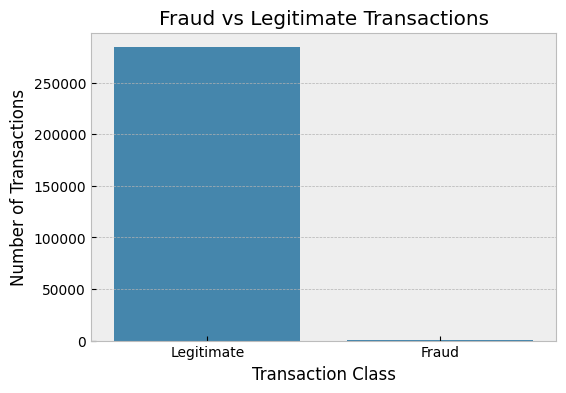

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

### conclusion:
The graph shows that legitimate transactions are much higher than
fraudulent transactions. This indicates a significant class imbalance
in the dataset.

2. Transaction Amount Analysis

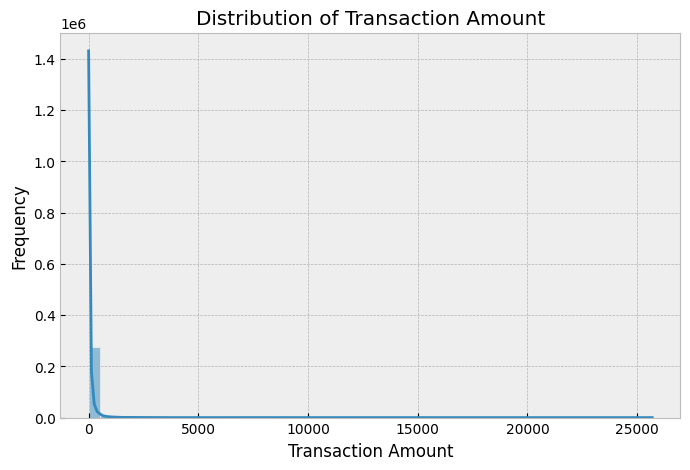

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Amount'], bins=50, kde=True)

plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

### conclusion:-
The distribution shows that most transactions have relatively low
transaction amounts, while only a small number of transactions have
very high amounts. Therefore, the transaction amount distribution is
highly right-skewed.

In [10]:
#3. Fraud vs Legitimate Transaction Amount

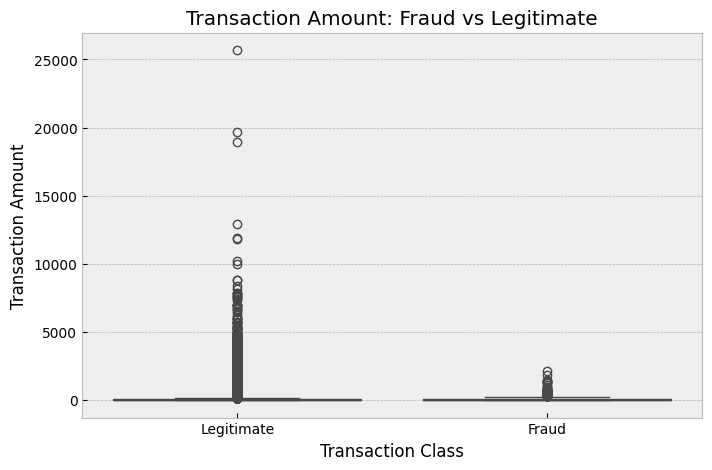

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount: Fraud vs Legitimate')
plt.xlabel('Transaction Class')
plt.ylabel('Transaction Amount')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

### conclusion:-
The distribution shows that most transactions have relatively low
transaction amounts, while only a small number of transactions have
very high amounts. Therefore, the transaction amount distribution is
highly right-skewed.

3. Fraud vs Legitimate Transaction Amount

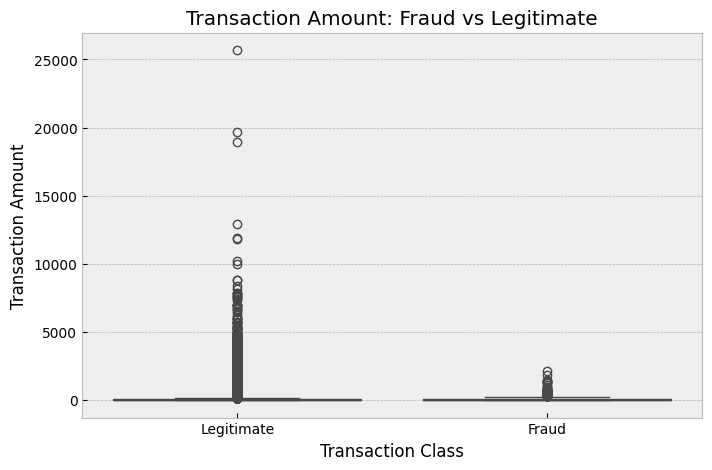

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount: Fraud vs Legitimate')
plt.xlabel('Transaction Class')
plt.ylabel('Transaction Amount')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

### conclusion:-
The boxplot shows that the transaction amount distribution differs
between legitimate and fraudulent transactions. Legitimate transactions
contain a wider range of transaction amounts, while fraudulent
transactions are generally concentrated within a lower amount range.

4. Transaction Time Analysis

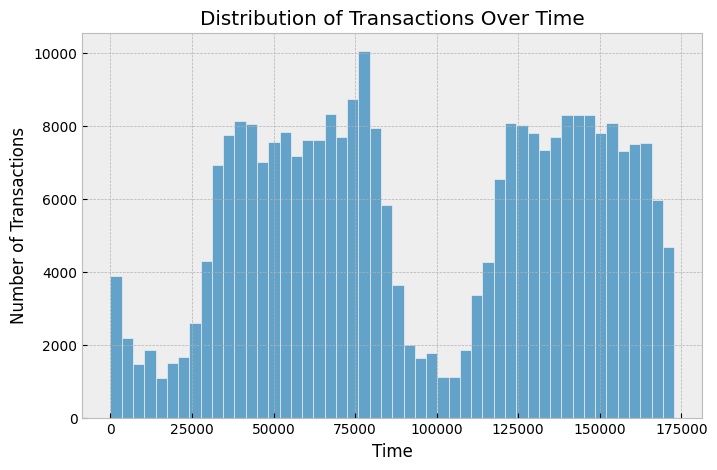

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Time', bins=50)

plt.title('Distribution of Transactions Over Time')
plt.xlabel('Time')
plt.ylabel('Number of Transactions')

plt.show()

### conclusion:-
The graph shows that transactions are distributed across different
time periods, with varying transaction frequencies. This indicates
that transaction activity changes over time and can be further
analyzed to identify time-related patterns in fraudulent transactions.

5. Fraudulent Transactions Over Time

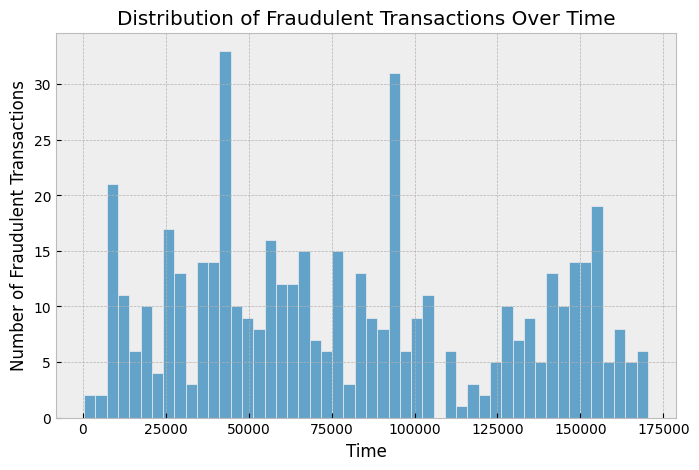

In [14]:
fraud_df = df[df['Class'] == 1]

plt.figure(figsize=(8,5))

sns.histplot(fraud_df['Time'], bins=50)

plt.title('Distribution of Fraudulent Transactions Over Time')
plt.xlabel('Time')
plt.ylabel('Number of Fraudulent Transactions')

plt.show()

### conclusion:-
The graph shows that fraudulent transactions occur throughout
different time periods, but their frequency varies across the
timeline. This indicates that fraudulent activity is not evenly
distributed over time and may have specific periods with higher
fraud occurrences.

6. Correlation Analysis

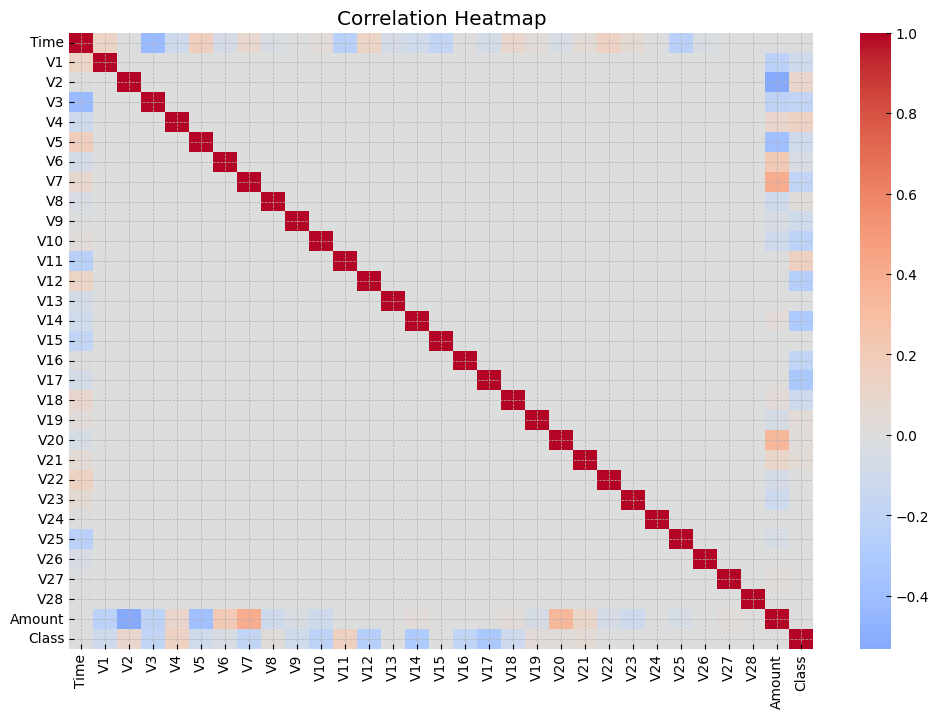

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap='coolwarm', center=0)

plt.title('Correlation Heatmap')

plt.show()

### conclusion:-
The correlation heatmap shows the relationships between the numerical
features in the dataset. Most features have relatively low correlation
with each other, while some features show stronger positive or negative
relationships. The heatmap also helps identify features that have a
stronger relationship with the target variable, Class, which can be
useful for further fraud detection analysis.

7. Feature Distribution Analysis

<Figure size 1200x600 with 0 Axes>

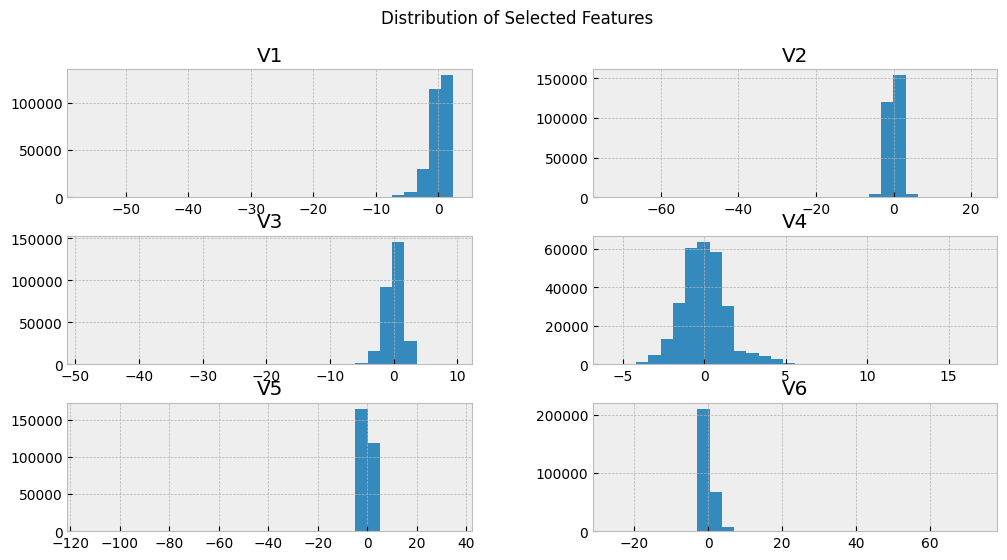

In [16]:
features = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']

plt.figure(figsize=(12,6))

df[features].hist(figsize=(12,6), bins=30)

plt.suptitle('Distribution of Selected Features')

plt.show()

### conclusion:-
The feature distributions show that the selected transaction features
have different patterns and ranges. Some features are concentrated
around specific values, while others show wider variation. These
differences can help identify unusual transaction patterns associated
with fraudulent activity.

8. Fraud vs Legitimate Feature Comparison

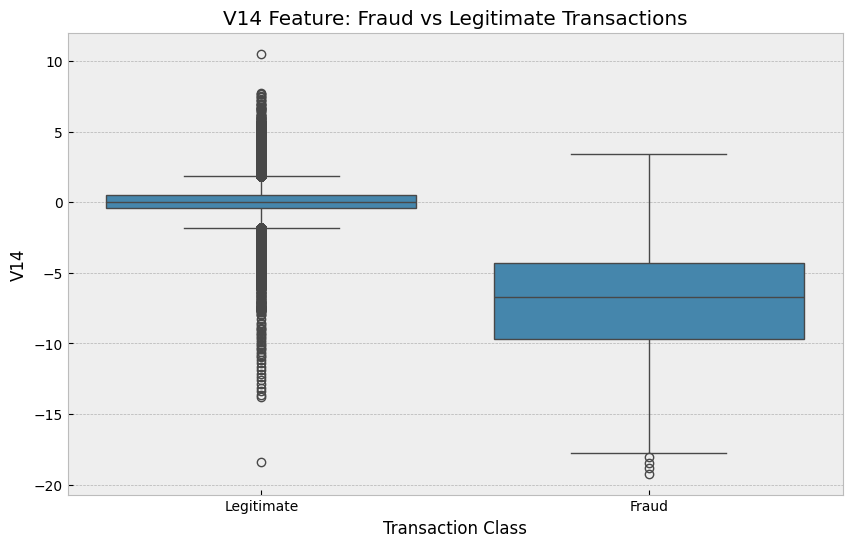

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Class', y='V14', data=df)

plt.title('V14 Feature: Fraud vs Legitimate Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('V14')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

### conclusion:-
The boxplot shows a noticeable difference in the distribution of V14
between legitimate and fraudulent transactions. This indicates that
V14 may contain useful information for distinguishing fraudulent
transactions from legitimate transactions.

9.V10 Feature: Fraud vs Legitimate Transactions

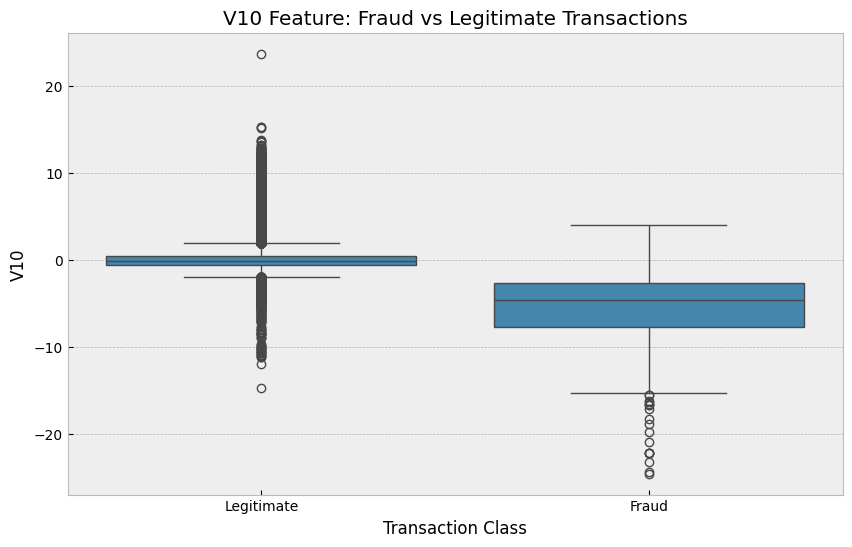

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Class', y='V10', data=df)

plt.title('V10 Feature: Fraud vs Legitimate Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('V10')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

### conclusion:-
The boxplot shows a difference in the V10 feature distribution
between legitimate and fraudulent transactions. This suggests that
V10 may provide useful information for distinguishing fraudulent
transactions from legitimate transactions.

10. V12 Feature: Fraud vs Legitimate Transactions

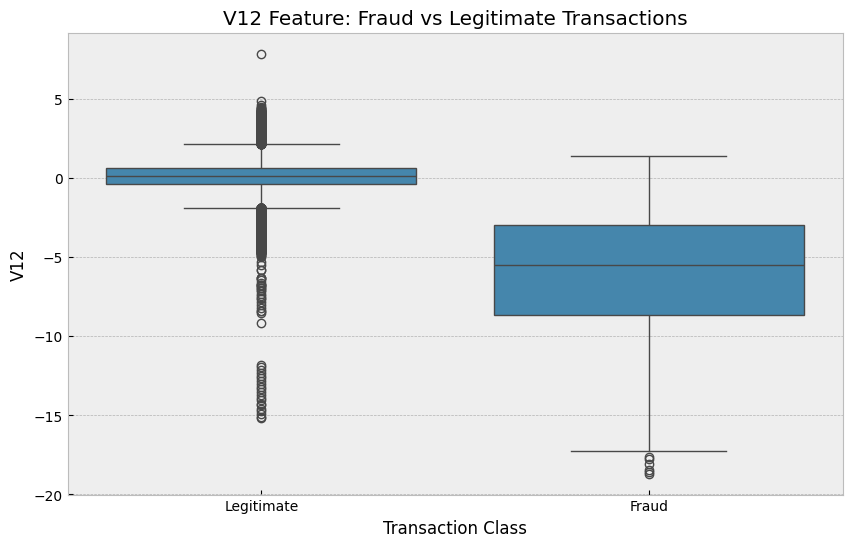

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Class', y='V12', data=df)

plt.title('V12 Feature: Fraud vs Legitimate Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('V12')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

###
Conclusion

The boxplot shows a clear difference in the V12 feature distribution between legitimate and fraudulent transactions. The fraudulent transactions show a different range and spread compared to legitimate transactions. This indicates that V12 can be a useful feature for identifying unusual transaction patterns and detecting potential fraud.

11. V17 Feature: Fraud vs Legitimate Transactions

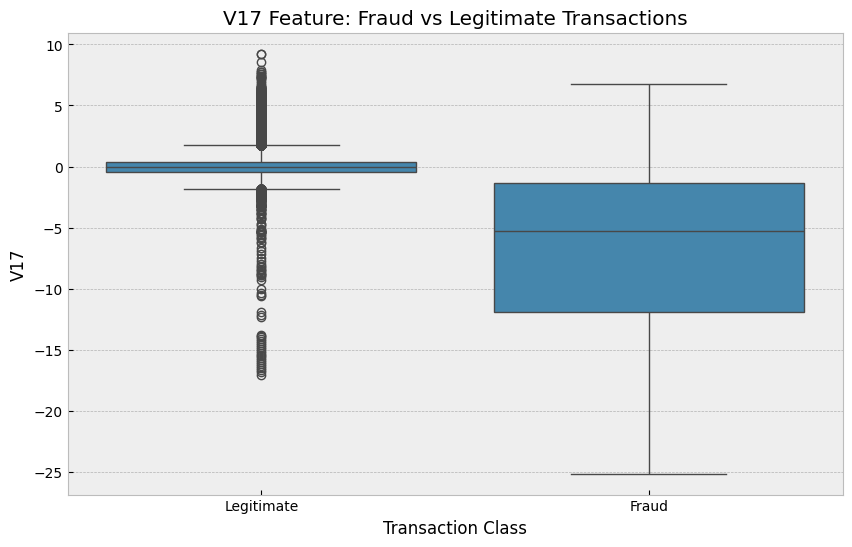

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Class', y='V17', data=df)

plt.title('V17 Feature: Fraud vs Legitimate Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('V17')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

Conclusion:
The transaction amount distribution shows that legitimate transactions occur across a wider range of amounts, while fraudulent transactions are generally concentrated around lower transaction amounts. This indicates that transaction amount can be useful when analyzing fraud risk.

13. Transaction Amount Comparison

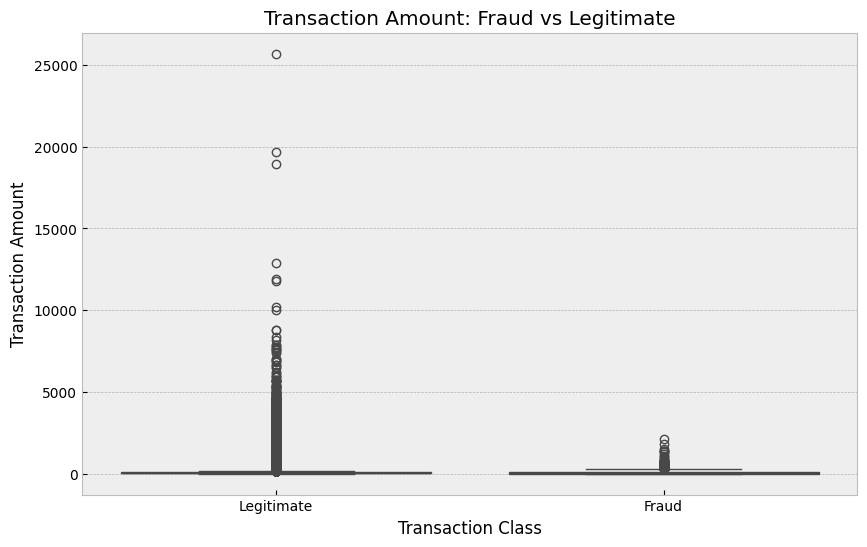

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount: Fraud vs Legitimate')
plt.xlabel('Transaction Class')
plt.ylabel('Transaction Amount')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

Conclusion:
The boxplot shows the difference in transaction amount between legitimate and fraudulent transactions. It also highlights the presence of extreme values in the transaction data. Therefore, transaction amount should be considered as one of the factors during fraud risk analysis.

14. Fraud Distribution by Transaction Time

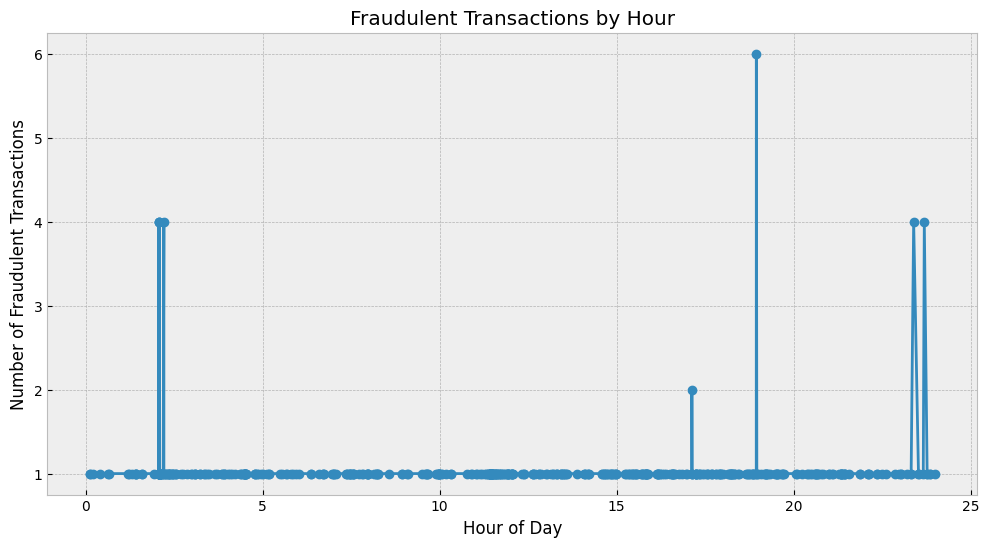

In [22]:
df['Hour'] = (df['Time'] / 3600) % 24

fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()

plt.figure(figsize=(12,6))

fraud_by_hour.plot(kind='line', marker='o')

plt.title('Fraudulent Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraudulent Transactions')

plt.grid(True)

plt.show()

Conclusion:
The hourly analysis shows how fraudulent transactions are distributed throughout the day. Certain time periods may show comparatively higher fraud activity. Time-based patterns can therefore be useful for monitoring and identifying potentially risky transactions.

15. Fraud Transaction Amount Analysis

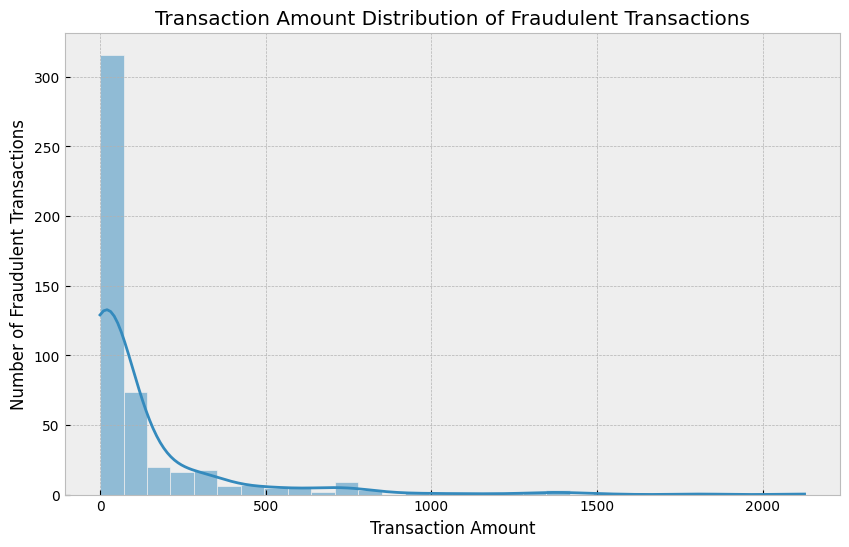

In [23]:
fraud_transactions = df[df['Class'] == 1]

plt.figure(figsize=(10,6))

sns.histplot(fraud_transactions['Amount'], bins=30, kde=True)

plt.title('Transaction Amount Distribution of Fraudulent Transactions')
plt.xlabel('Transaction Amount')
plt.ylabel('Number of Fraudulent Transactions')

plt.show()

Conclusion:
The distribution shows the range of transaction amounts associated with fraudulent transactions. Most fraudulent transactions are concentrated within a particular amount range, while a smaller number of transactions have relatively higher amounts. This helps understand the financial characteristics of fraudulent activity.

## 1. Fraud vs Legitimate Transactions

This analysis compares fraudulent and legitimate transactions.

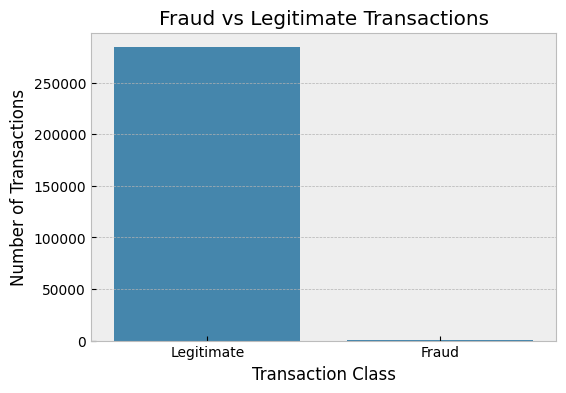

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

### Conclusion

The graph shows a significant difference between legitimate and fraudulent transactions, indicating class imbalance.

## 2. Transaction Amount Analysis

This analysis compares transaction amounts for fraud and legitimate transactions.

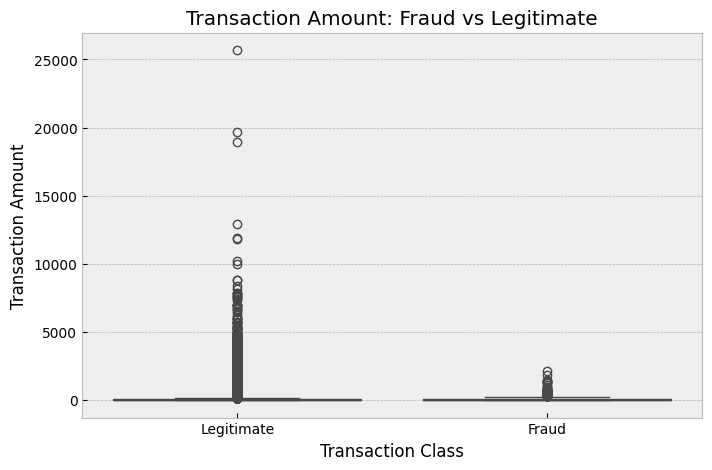

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount: Fraud vs Legitimate')
plt.xlabel('Transaction Class')
plt.ylabel('Transaction Amount')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

### Conclusion

The transaction amounts show different patterns between fraudulent and legitimate transactions.

## 3. Average Transaction Amount

This analysis compares the average transaction amount for both classes.

In [26]:
avg_amount = df.groupby('Class')['Amount'].mean()

print(avg_amount)

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64


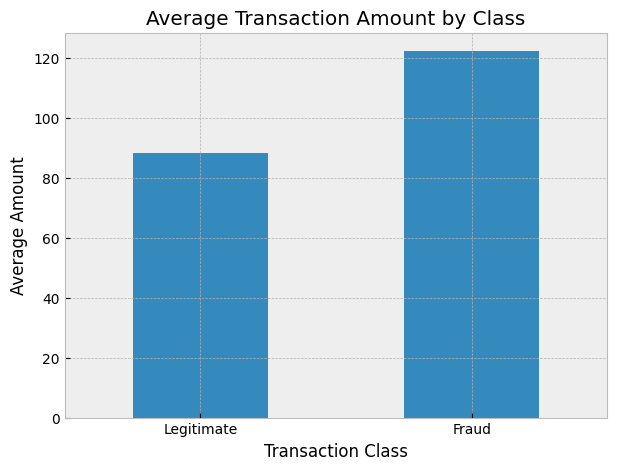

In [27]:
plt.figure(figsize=(7,5))

avg_amount.plot(kind='bar')

plt.title('Average Transaction Amount by Class')
plt.xlabel('Transaction Class')
plt.ylabel('Average Amount')
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)

plt.show()

### Conclusion

The average transaction amount differs between legitimate and fraudulent transactions.

## 4. Fraudulent Transaction Distribution

This analysis shows the distribution of transaction amounts for fraudulent transactions.

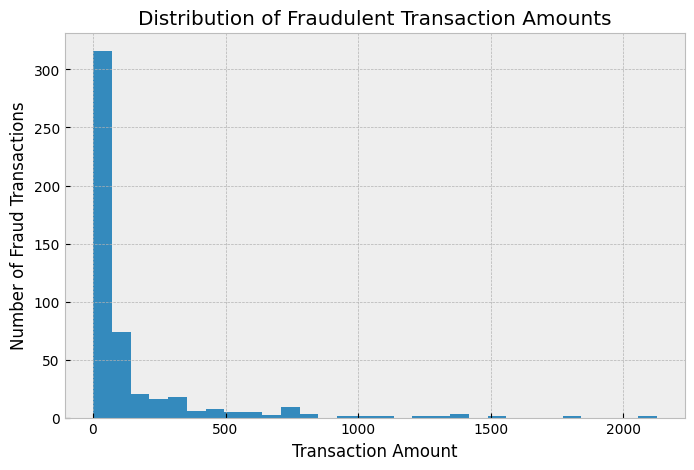

In [28]:
fraud_df = df[df['Class'] == 1]

plt.figure(figsize=(8,5))

plt.hist(fraud_df['Amount'], bins=30)

plt.title('Distribution of Fraudulent Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Number of Fraud Transactions')

plt.show()

### Conclusion

Fraudulent transactions occur across different transaction amount ranges.

## 5. Correlation Analysis

This analysis identifies features that are related to the fraud class.

In [29]:
correlation = df.corr()['Class'].sort_values(ascending=False)

print(correlation)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
Hour     -0.017082
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


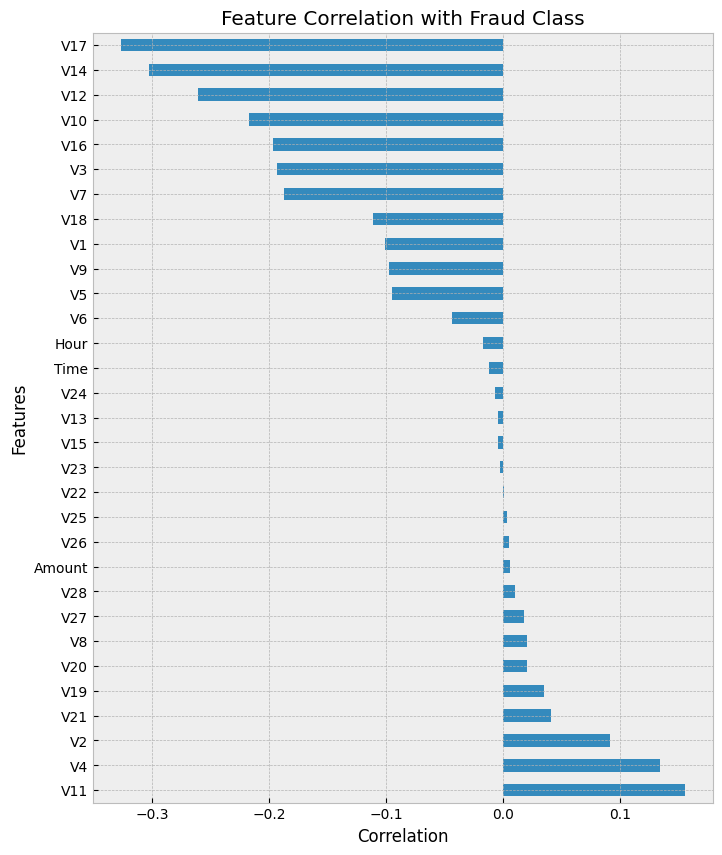

In [30]:
plt.figure(figsize=(8,10))

correlation.drop('Class').plot(kind='barh')

plt.title('Feature Correlation with Fraud Class')
plt.xlabel('Correlation')
plt.ylabel('Features')

plt.show()

### Conclusion

Some features show stronger relationships with the fraud class and may help in fraud detection.

## 6. Data Preparation

The Class column is used as the target variable and the remaining columns are used as features.

In [31]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (284807, 31)
Target: (284807,)


### Conclusion

The dataset has been separated into input features and the target variable.

## 7. Train-Test Split

The dataset is divided into training and testing data for model building and evaluation.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 31)
Testing data: (56962, 31)


### Conclusion

The dataset was successfully divided into training and testing sets while maintaining the class ratio.

## 8. Feature Scaling

Scaling is applied to the Time and Amount features before model training.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[['Time', 'Amount']] = scaler.fit_transform(
    X_train[['Time', 'Amount']]
)

X_test[['Time', 'Amount']] = scaler.transform(
    X_test[['Time', 'Amount']]
)

### Conclusion

The Time and Amount features were standardized for machine learning.

## 9. Handling Class Imbalance using SMOTE

SMOTE is used to balance the minority fraud class in the training data.

In [34]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

print(df.shape)

(284807, 31)


In [35]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (284807, 30)
Target: (284807,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[['Time', 'Amount']] = scaler.fit_transform(
    X_train[['Time', 'Amount']]
)

X_test[['Time', 'Amount']] = scaler.transform(
    X_test[['Time', 'Amount']]
)

print("Scaling completed successfully!")

Scaling completed successfully!


In [38]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [39]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_smote, y_train_smote)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



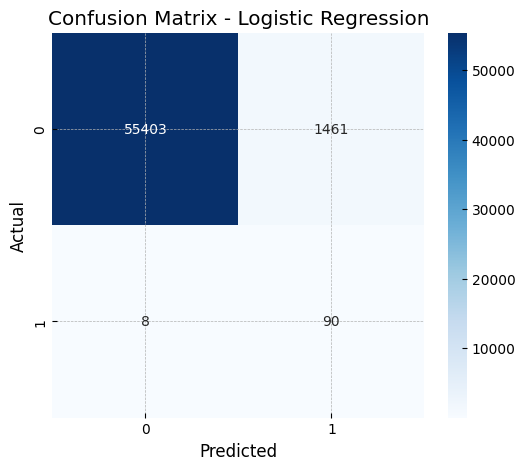

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

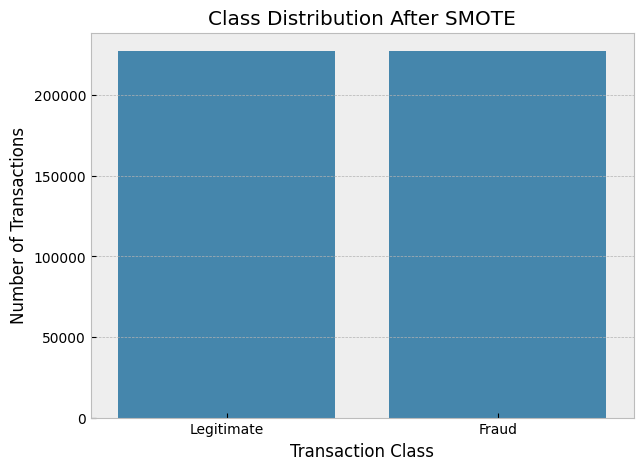

In [42]:
plt.figure(figsize=(7,5))

sns.countplot(x=y_train_smote)

plt.title('Class Distribution After SMOTE')
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.show()

### Conclusion

SMOTE balanced the training data and increased the representation of fraudulent transactions.

## 10. Logistic Regression

Logistic Regression is used as a baseline fraud classification model.

In [60]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_smote, y_train_smote)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

### Conclusion

The Logistic Regression model was trained to classify transactions as legitimate or fraudulent.

## 11. Logistic Regression Evaluation

The model is evaluated using precision, recall, F1-score and confusion matrix.

In [44]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



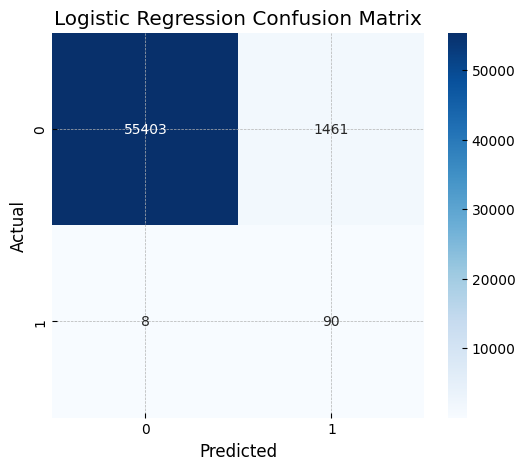

In [45]:
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Conclusion

The evaluation shows how effectively Logistic Regression detects fraudulent transactions.

## 12. Random Forest

Random Forest is used to capture complex patterns in transaction data.

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

### Conclusion

The Random Forest model was trained to identify fraudulent transactions.

## 13. Random Forest Evaluation

The Random Forest model is evaluated using classification metrics and a confusion matrix.

In [47]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



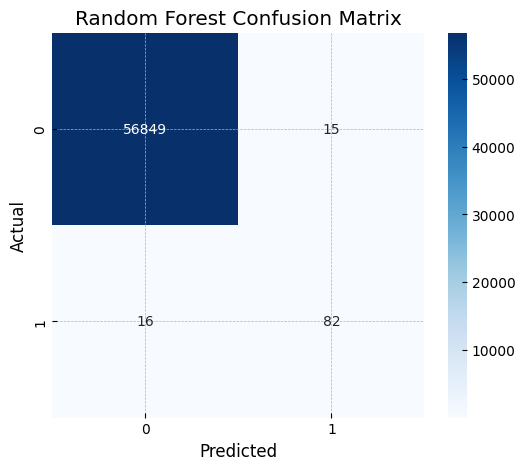

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Conclusion

The Random Forest model provides a strong classification approach for detecting fraudulent transactions.

## 14. Model Performance Comparison

The performance of both models is compared using important classification metrics.

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.974211,0.058027,0.918367,0.109157
1,Random Forest,0.999456,0.845361,0.836735,0.841026


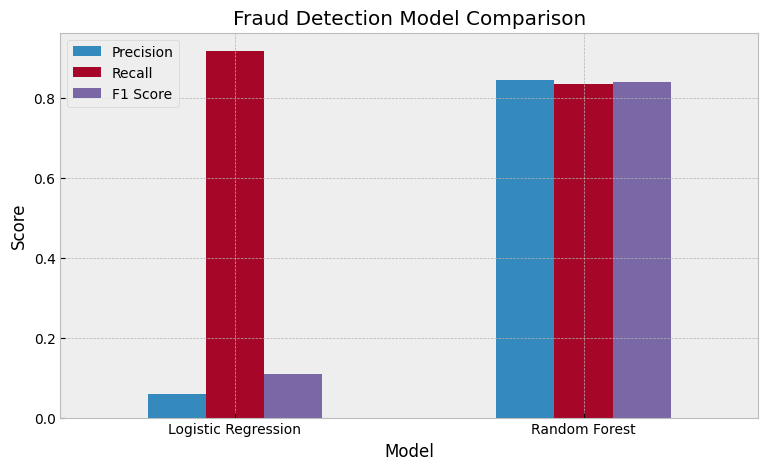

In [50]:
results.set_index('Model')[['Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('Fraud Detection Model Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)

plt.show()

### Conclusion

The models can be compared using precision, recall and F1-score to select a suitable fraud detection model.

## 15. ROC-AUC Analysis

ROC-AUC is used to measure the ability of the models to distinguish fraud from legitimate transactions.

In [51]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_log = roc_auc_score(y_test, y_prob_logistic)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression AUC:", auc_log)
print("Random Forest AUC:", auc_rf)

Logistic Regression AUC: 0.9698631105509169
Random Forest AUC: 0.973103297664029


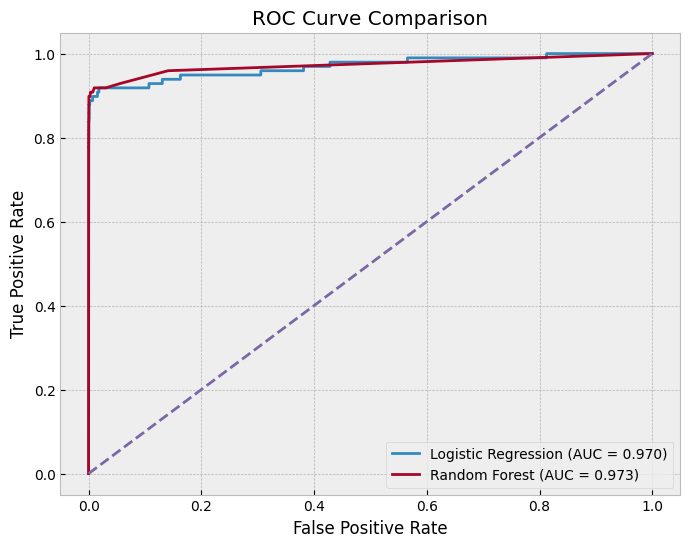

In [52]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f'Logistic Regression (AUC = {auc_log:.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.3f})'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.show()

### Conclusion

The ROC-AUC results show how well each model distinguishes fraudulent transactions from legitimate transactions.

## 16. Feature Importance

Feature importance identifies the features that contribute most to the Random Forest predictions.

In [53]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

V14    0.195607
V10    0.110459
V4     0.106133
V12    0.095085
V17    0.085002
V3     0.060455
V11    0.056356
V16    0.043757
V2     0.036986
V9     0.026203
dtype: float64


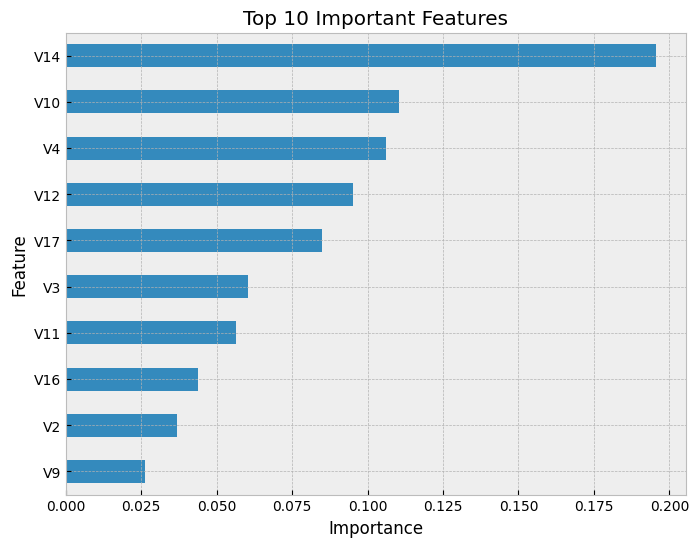

In [54]:
plt.figure(figsize=(8,6))

feature_importance.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

### Conclusion

The feature importance analysis identifies the most useful features for fraud prediction.

## 17. Risk Interpretation

The model assigns risk levels to transactions based on their predicted fraud probability.

In [55]:
risk_prediction = pd.DataFrame({
    'Actual_Class': y_test.values,
    'Predicted_Class': y_pred_rf,
    'Fraud_Probability': y_prob_rf
})

risk_prediction['Risk_Level'] = pd.cut(
    risk_prediction['Fraud_Probability'],
    bins=[-0.01, 0.30, 0.70, 1.01],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_prediction.head(10)

,Actual_Class,Predicted_Class,Fraud_Probability,Risk_Level
0,0,0,0.00,Low Risk
1,0,0,0.00,Low Risk
2,0,0,0.02,Low Risk
3,0,0,0.00,Low Risk
4,0,0,0.00,Low Risk
5,0,0,0.00,Low Risk
6,0,0,0.00,Low Risk
7,0,0,0.00,Low Risk
8,0,0,0.00,Low Risk
9,0,0,0.00,Low Risk


In [56]:
risk_prediction['Risk_Level'].value_counts()

Risk_Level
Low Risk       56843
High Risk         82
Medium Risk       37
Name: count, dtype: int64

### Conclusion

High-risk transactions can be prioritized for further investigation by the risk team.

## 19. Anomaly Detection using Isolation Forest

Isolation Forest is used to identify unusual transactions that may indicate fraudulent activity.

In [57]:
from sklearn.ensemble import IsolationForest

isolation_model = IsolationForest(
    contamination=0.0017,
    random_state=42
)

anomaly_pred = isolation_model.fit_predict(X)

df['Anomaly'] = anomaly_pred

print(df['Anomaly'].value_counts())

Anomaly
 1    284322
-1       485
Name: count, dtype: int64


Fraud/Anomaly comparison


In [58]:
anomaly_fraud = df[df['Anomaly'] == -1]

print("Detected Anomalies:", len(anomaly_fraud))
print("Fraud transactions among anomalies:",
      (anomaly_fraud['Class'] == 1).sum())

Detected Anomalies: 485
Fraud transactions among anomalies: 125


## 20. Anomaly Detection Results

This analysis shows the transactions identified as unusual by the Isolation Forest model.

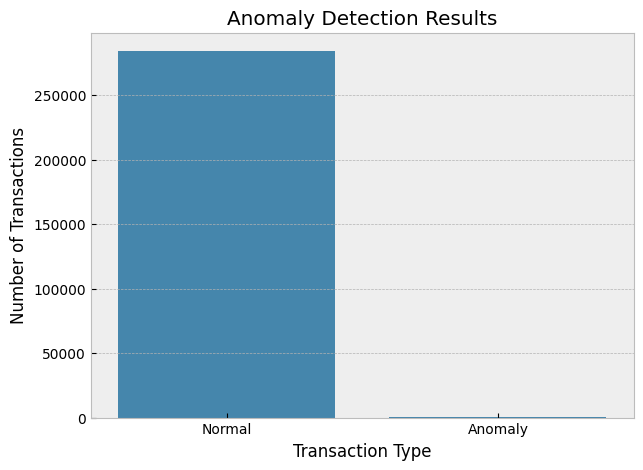

In [59]:
plt.figure(figsize=(7,5))

sns.countplot(x=df['Anomaly'].map({
    1: 'Normal',
    -1: 'Anomaly'
}))

plt.title('Anomaly Detection Results')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')

plt.show()

### Conclusion

Isolation Forest identified unusual transactions that can be further investigated as potential fraud risks.

## 18. Final Conclusion

This project analyzed credit card transactions, handled class imbalance, and built machine learning models to detect fraud.

The analysis demonstrates how data science techniques can support financial fraud detection and risk analysis.